# 02: Data Backend, DoubleMLData, and Design Setup

This lesson is about the part of DoubleML that looks simple but carries a lot of causal responsibility: the data backend. Before fitting a model, DoubleML needs to know which column is the outcome, which column is the treatment, which columns are controls, which columns are instruments, which columns define clusters or panels, and which columns are design-specific variables such as running scores or selection indicators.

The data backend is more than a convenience wrapper. It is where the causal design becomes an executable object. If the column roles are wrong, the estimand is wrong. If a post-treatment variable is placed in the controls, the nuisance model can adjust away part of the effect. If an instrument is accidentally treated as an ordinary control, the IV design is no longer represented. If clustered observations are treated as independent, uncertainty can be overstated.

This tutorial therefore focuses on design setup, schema checks, and backend construction before model fitting. The actual estimators come in later notebooks.

Estimated runtime: less than 1 minute.

## Learning Goals

By the end, you should be able to:

- explain why variable roles define the causal estimand;
- build `DoubleMLData` objects for standard, IV, multi-treatment, and clustered designs;
- understand when `DoubleMLPanelData`, `DoubleMLRDDData`, and `DoubleMLSSMData` are relevant;
- create a repeatable data audit before fitting any DoubleML model;
- detect common setup mistakes such as missing values, overlapping roles, post-treatment controls, and weak treatment variation;
- save a data-design report that can be reused before model fitting.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Data Backend, DoubleMLData, And Design Setup**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the notebook separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment is chosen to make the library behavior visible while keeping the causal target, assumptions, and diagnostics easy to audit.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

A DoubleML data backend organizes the observed data as

$$
W_i=(Y_i,D_i,X_i,Z_i),
$$

where $Y_i$ is the outcome, $D_i$ is the treatment, $X_i$ is the control vector, and $Z_i$ is present for instrumental-variable designs. The backend does not identify a causal effect by itself. It maps columns to mathematical roles.

For a partially linear model, the final stage is residualized,

$$
Y_i-\widehat g(X_i) \approx \theta\{D_i-\widehat m(X_i)\}.
$$



The notebook follows a practical workflow:

1. define the theory of data roles and estimands;
2. create a synthetic master dataset with many possible design columns;
3. audit missingness, numeric types, variation, correlations, and role conflicts;
4. construct standard `DoubleMLData` objects;
5. construct IV, multi-treatment, clustered, panel, RDD, and sample-selection backends;
6. show common mistakes and how to catch them early;
7. finish with a reusable design checklist.





## Tutorial Workflow

#### Setup

The code below imports the scientific Python stack, configures output folders, and imports DoubleML. We suppress known non-substantive notebook warnings so the executed notebook stays readable.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import inspect
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doubleml":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
warnings.filterwarnings("ignore", message="DoubleMLDIDData is deprecated.*")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import doubleml as dml

NOTEBOOK_PREFIX = "02"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

print(f"Project root: {PROJECT_ROOT}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"DoubleML version: {getattr(dml, '__version__', 'not exposed')}")


Project root: /home/apex/Documents/portfolio
Output folder: /home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs
DoubleML version: 0.11.2


The setup mirrors the earlier notebooks so outputs are organized consistently. All generated files in this lesson use the `02_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Package Versions

Backend behavior and constructor signatures can change across versions, so we record the environment used for this run.

In [2]:
from importlib import metadata

packages = ["doubleml", "numpy", "pandas", "scikit-learn", "matplotlib", "seaborn"]
version_rows = []
for package in packages:
    try:
        version = metadata.version(package)
    except metadata.PackageNotFoundError:
        version = None
    version_rows.append({"package": package, "version": version})
version_table = pd.DataFrame(version_rows)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)


,package,version
0,doubleml,0.11.2
1,numpy,2.4.4
2,pandas,3.0.2
3,scikit-learn,1.6.1
4,matplotlib,3.10.9
5,seaborn,0.13.2


This table is especially useful for a backend tutorial because class names and preferred containers can evolve over time.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Theory: Data Roles Define the Estimand

A DoubleML estimator does not discover the role of each column. You tell it the roles. That role assignment defines which score is evaluated and which nuisance functions are estimated.

For a standard unconfoundedness design, a simplified role map is:

- `Y`: the outcome we want to explain causally;
- `D`: the treatment or exposure whose effect is targeted;
- `X`: pre-treatment controls used to make treatment assignment as-good-as-random conditional on `X`;
- optional clusters: groups that affect dependence in the data;
- optional instruments `Z`: variables that shift treatment but affect the outcome only through treatment under IV assumptions.

For other designs, the backend may also need:

- `t_col`: a time column for panel or DID-style data;
- `id_col`: a unit identifier for panel data;
- `score_col`: the running variable in an RDD setup;
- `s_col`: a selection indicator for sample-selection models.

The central rule is: if a column's role is conceptually wrong, a successful Python object can still encode a bad causal design.

The following table turns this theory into a role glossary. This is the checklist to keep beside every DoubleML data object.

| role | typical_argument | causal_meaning | common_mistake |
| --- | --- | --- | --- |
| outcome | y_col | Final outcome whose causal response is being studied. | Using an intermediate or post-treatment measure as the outcome by accident. |
| treatment | d_cols | Exposure, policy, product change, or intervention variable whose effect is targeted. | Mixing multiple treatments without deciding whether the estimand is joint or separate. |
| controls | x_cols | Pre-treatment adjustment variables used by nuisance learners. | Including post-treatment mediators or colliders as controls. |
| instruments | z_cols | Variables that shift treatment but are excluded from the outcome equation except through treatment. | Treating an instrument like an ordinary confounder or using a weak instrument. |
| clusters | cluster_cols | Group identifiers for dependence across rows. | Ignoring repeated users, markets, schools, stores, or sessions as independent rows. |
| time and unit identifiers | t_col, id_col | Panel structure for repeated observations over time. | Using row order instead of explicit time and unit columns. |
| running score | score_col | RDD assignment variable around a cutoff. | Using a transformed treatment indicator instead of the underlying running variable. |
| selection indicator | s_col | Indicator for whether the outcome is observed or the row is selected into the analytic sample. | Dropping unselected rows before modeling selection. |


The glossary should feel conservative. Most DoubleML mistakes are not exotic math failures; they are role-assignment mistakes made before the estimator starts.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


### Installed Data Containers

The next cell inspects the data-container classes available in the installed DoubleML version. This makes the notebook version-aware and shows which constructor arguments matter.

In [3]:
# Fit or evaluate the model objects used in the Installed Data Containers section.
container_names = [
    "DoubleMLData",
    "DoubleMLClusterData",
    "DoubleMLPanelData",
    "DoubleMLDIDData",
    "DoubleMLRDDData",
    "DoubleMLSSMData",
]
container_rows = []
for name in container_names:
    cls = getattr(dml, name, None)
    if cls is None:
        container_rows.append({"container": name, "available": False, "signature": None, "note": "not available"})
        continue
    doc = inspect.getdoc(cls) or ""
    first_doc_line = doc.splitlines()[0] if doc else ""
    note = "available"
    if "deprecated" in doc.lower():
        note = "available but not preferred in this version"
    container_rows.append(
        {
            "container": name,
            "available": True,
            "signature": str(inspect.signature(cls)),
            "note": note,
            "doc_summary": first_doc_line,
        }
    )
container_table = pd.DataFrame(container_rows)
container_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_container_signatures.csv", index=False)
display(container_table)


,container,available,signature,note,doc_summary
0,DoubleMLData,True,"(data, y_col, d_cols, x_cols=None, z_cols=None, cluster_cols=None, use_other_treat_as_covariate=True, force_all_x_finite=True, force_all_d_finite=True)",available,Double machine learning data-backend.
1,DoubleMLClusterData,True,"(data, y_col, d_cols, cluster_cols, x_cols=None, z_cols=None, t_col=None, s_col=None, use_other_treat_as_covariate=True, force_all_x_finite=True)",available but not preferred in this version,Backwards compatibility wrapper for DoubleMLData with cluster_cols.
2,DoubleMLPanelData,True,"(data, y_col, d_cols, t_col, id_col, x_cols=None, z_cols=None, static_panel=False, use_other_treat_as_covariate=True, force_all_x_finite=True, datetime_unit='M')",available,Double machine learning data-backend for panel data in long format.
3,DoubleMLDIDData,True,"(data, y_col, d_cols, x_cols=None, z_cols=None, t_col=None, cluster_cols=None, use_other_treat_as_covariate=True, force_all_x_finite=True, force_all_d_finite=True)",available,Double machine learning data-backend for Difference-in-Differences models.
4,DoubleMLRDDData,True,"(data, y_col, d_cols, score_col, x_cols=None, z_cols=None, cluster_cols=None, use_other_treat_as_covariate=True, force_all_x_finite=True, force_all_d_finite=True)",available,Double machine learning data-backend for Regression Discontinuity Design models.
5,DoubleMLSSMData,True,"(data, y_col, d_cols, x_cols=None, z_cols=None, s_col=None, cluster_cols=None, use_other_treat_as_covariate=True, force_all_x_finite=True, force_all_d_finite=True)",available,Double machine learning data-backend for Sample Selection Models.


The preferred starting point is `DoubleMLData`. Specialized containers become useful when the design itself needs extra structure, such as unit-time panels, RDD running scores, or sample-selection indicators.

#### Create a Master Example Dataset

We now create one synthetic master dataset containing columns for several possible designs. Not every column belongs in every design. That is deliberate: a realistic data table often contains outcomes, treatments, controls, instruments, identifiers, timestamps, post-treatment variables, and helper columns all at once.

The point of the backend workflow is to choose the correct subset and assign roles carefully.

In [4]:
# Define reusable helpers for the Create A Master Example Dataset section.
def simulate_master_backend_data(n_rows=900, seed=RANDOM_SEED):
    """
    Idea: Simulate the master backend data scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    n_rows : object
        Number of rows to generate, display, or sample.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    pd.DataFrame or dict
        Named df object assembled by simulate master backend data.
    """
    rng = np.random.default_rng(seed)
    user_id = np.arange(n_rows)
    cluster_id = rng.integers(0, 30, size=n_rows)
    time_period = rng.integers(0, 4, size=n_rows)

    x_prior_activity = rng.normal(size=n_rows)
    x_account_age = rng.uniform(0, 1, size=n_rows)
    x_region_score = rng.normal(size=n_rows)
    x_risk_score = rng.normal(size=n_rows)
    x_binary_segment = rng.binomial(1, 0.45, size=n_rows)

    encouragement = rng.binomial(1, 1 / (1 + np.exp(-0.5 * x_prior_activity + 0.3 * x_binary_segment)), size=n_rows)
    treatment_cont = (
        0.70 * encouragement
        + 0.65 * x_prior_activity
        - 0.35 * x_risk_score
        + 0.25 * x_binary_segment
        + rng.normal(size=n_rows)
    )
    treatment_bin_prob = 1 / (1 + np.exp(-0.65 * x_prior_activity + 0.45 * x_account_age - 0.25 * x_risk_score))
    treatment_bin = rng.binomial(1, treatment_bin_prob, size=n_rows)
    secondary_treatment = 0.35 * treatment_cont + 0.40 * x_region_score + rng.normal(size=n_rows)

    outcome = (
        1.20 * treatment_cont
        + 0.80 * x_prior_activity
        + 0.45 * x_account_age
        - 0.50 * x_risk_score
        + 0.30 * x_binary_segment
        + 0.15 * cluster_id / max(cluster_id.max(), 1)
        + rng.normal(size=n_rows)
    )

    post_treatment_engagement = 0.75 * treatment_cont + 0.40 * outcome + rng.normal(size=n_rows)
    running_score = rng.normal(size=n_rows)
    rdd_treatment = (running_score >= 0).astype(int)
    selected = rng.binomial(1, 1 / (1 + np.exp(-0.50 * x_prior_activity + 0.30 * treatment_bin)), size=n_rows)

    df = pd.DataFrame(
        {
            "user_id": user_id,
            "cluster_id": cluster_id,
            "time_period": time_period,
            "y_outcome": outcome,
            "d_continuous": treatment_cont,
            "d_binary": treatment_bin,
            "d_secondary": secondary_treatment,
            "z_encouragement": encouragement,
            "x_prior_activity": x_prior_activity,
            "x_account_age": x_account_age,
            "x_region_score": x_region_score,
            "x_risk_score": x_risk_score,
            "x_binary_segment": x_binary_segment,
            "post_treatment_engagement": post_treatment_engagement,
            "running_score": running_score,
            "d_rdd": rdd_treatment,
            "selected": selected,
        }
    )
    return df

master_df = simulate_master_backend_data()
master_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_master_backend_teaching_data.csv", index=False)
display(master_df.head())
print(f"Shape: {master_df.shape}")


,user_id,cluster_id,time_period,y_outcome,d_continuous,d_binary,d_secondary,z_encouragement,x_prior_activity,x_account_age,x_region_score,x_risk_score,x_binary_segment,post_treatment_engagement,running_score,d_rdd,selected
0,0,2,0,-1.346044,-0.618913,0,-0.632208,0,-0.584874,0.440963,-1.057387,-0.742679,1,-0.730301,0.006586,1,0
1,1,23,0,3.806793,0.771057,0,-1.342448,0,-0.046587,0.742906,-1.897814,-1.184685,1,1.451503,0.719562,1,0
2,2,19,0,3.416268,2.259870,0,1.663593,1,0.278864,0.237062,1.286590,1.033809,1,4.947101,-0.539540,0,1
3,3,13,3,1.212854,-0.890061,0,-0.495956,0,-1.007893,0.829750,-0.826809,-1.704100,0,-0.021799,0.689910,1,0
4,4,12,1,2.053458,1.241551,0,0.353673,1,0.724283,0.545798,-0.020706,0.926856,1,1.985428,-1.455629,0,0


Shape: (900, 17)


The master table contains more columns than any single design should use. The next sections will carve it into different DoubleML backend objects.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


### Variable Dictionary

A variable dictionary is the first line of defense against role confusion. We mark each column's conceptual role and whether it is safe to use as a pre-treatment control in standard effect-estimation designs.

In [5]:
variable_dictionary = pd.DataFrame(
    [
        {"column": "user_id", "role_family": "identifier", "allowed_as_standard_control": False, "description": "Unique unit identifier."},
        {"column": "cluster_id", "role_family": "cluster", "allowed_as_standard_control": False, "description": "Cluster/group identifier for dependence."},
        {"column": "time_period", "role_family": "time", "allowed_as_standard_control": False, "description": "Discrete time period for panel-style data."},
        {"column": "y_outcome", "role_family": "outcome", "allowed_as_standard_control": False, "description": "Outcome variable."},
        {"column": "d_continuous", "role_family": "continuous treatment", "allowed_as_standard_control": False, "description": "Continuous treatment for PLR-style designs."},
        {"column": "d_binary", "role_family": "binary treatment", "allowed_as_standard_control": False, "description": "Binary treatment for IRM-style designs."},
        {"column": "d_secondary", "role_family": "secondary treatment", "allowed_as_standard_control": False, "description": "Additional treatment for multi-treatment examples."},
        {"column": "z_encouragement", "role_family": "instrument", "allowed_as_standard_control": False, "description": "Synthetic encouragement instrument."},
        {"column": "x_prior_activity", "role_family": "pre-treatment control", "allowed_as_standard_control": True, "description": "Baseline activity control."},
        {"column": "x_account_age", "role_family": "pre-treatment control", "allowed_as_standard_control": True, "description": "Baseline account-age control."},
        {"column": "x_region_score", "role_family": "pre-treatment control", "allowed_as_standard_control": True, "description": "Regional/context control."},
        {"column": "x_risk_score", "role_family": "pre-treatment control", "allowed_as_standard_control": True, "description": "Baseline risk control."},
        {"column": "x_binary_segment", "role_family": "pre-treatment control", "allowed_as_standard_control": True, "description": "Binary segment control."},
        {"column": "post_treatment_engagement", "role_family": "post-treatment variable", "allowed_as_standard_control": False, "description": "Generated after treatment; unsafe as a standard control."},
        {"column": "running_score", "role_family": "RDD running score", "allowed_as_standard_control": False, "description": "Assignment score for RDD examples."},
        {"column": "d_rdd", "role_family": "RDD treatment", "allowed_as_standard_control": False, "description": "Treatment induced by running-score cutoff."},
        {"column": "selected", "role_family": "selection indicator", "allowed_as_standard_control": False, "description": "Whether the row is selected/outcome observed."},
    ]
)
variable_dictionary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_variable_dictionary.csv", index=False)
display(variable_dictionary)


,column,role_family,allowed_as_standard_control,description
0,user_id,identifier,False,Unique unit identifier.
1,cluster_id,cluster,False,Cluster/group identifier for dependence.
2,time_period,time,False,Discrete time period for panel-style data.
3,y_outcome,outcome,False,Outcome variable.
4,d_continuous,continuous treatment,False,Continuous treatment for PLR-style designs.
5,d_binary,binary treatment,False,Binary treatment for IRM-style designs.
6,d_secondary,secondary treatment,False,Additional treatment for multi-treatment examples.
7,z_encouragement,instrument,False,Synthetic encouragement instrument.
8,x_prior_activity,pre-treatment control,True,Baseline activity control.
9,x_account_age,pre-treatment control,True,Baseline account-age control.


The row for `post_treatment_engagement` is especially important. It is predictive of the outcome, but it is not a valid standard control if the target is the effect of treatment on outcome.




## Diagnostics and Interpretation

### Basic Data Audit

A backend object can be created only when the data satisfies practical requirements: finite values, variation in treatment, expected data types, and no accidental missingness. This audit is intentionally generic so it can be reused before any DoubleML model.

In [6]:
data_audit = pd.DataFrame(
    {
        "dtype": master_df.dtypes.astype(str),
        "missing_rate": master_df.isna().mean(),
        "n_unique": master_df.nunique(),
        "mean": master_df.mean(numeric_only=True),
        "std": master_df.std(numeric_only=True),
        "min": master_df.min(numeric_only=True),
        "max": master_df.max(numeric_only=True),
    }
).reset_index(names="column")
data_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_master_data_audit.csv", index=False)
display(data_audit.round(3))


,column,dtype,missing_rate,n_unique,mean,std,min,max
0,user_id,int64,0.0,900,449.500,259.952,0.000,899.000
1,cluster_id,int64,0.0,30,14.644,8.754,0.000,29.000
2,time_period,int64,0.0,4,1.504,1.106,0.000,3.000
3,y_outcome,float64,0.0,900,0.874,2.582,-10.682,9.217
4,d_continuous,float64,0.0,900,0.434,1.345,-4.944,3.963
5,d_binary,int64,0.0,2,0.434,0.496,0.000,1.000
6,d_secondary,float64,0.0,900,0.189,1.177,-3.802,4.492
7,z_encouragement,int64,0.0,2,0.463,0.499,0.000,1.000
8,x_prior_activity,float64,0.0,900,-0.051,1.016,-3.648,2.914
9,x_account_age,float64,0.0,900,0.501,0.289,0.001,1.000


The audit shows no missingness and enough variation in the treatment columns. It also reminds us that identifier columns are numeric, which means they could accidentally slip into controls if we select columns mechanically.

### Correlation and Design Pressure

Correlation serves a different role than a causal design. It is a useful diagnostic. Here we inspect treatment, outcome, instrument, and control associations to understand the structure of the example data.

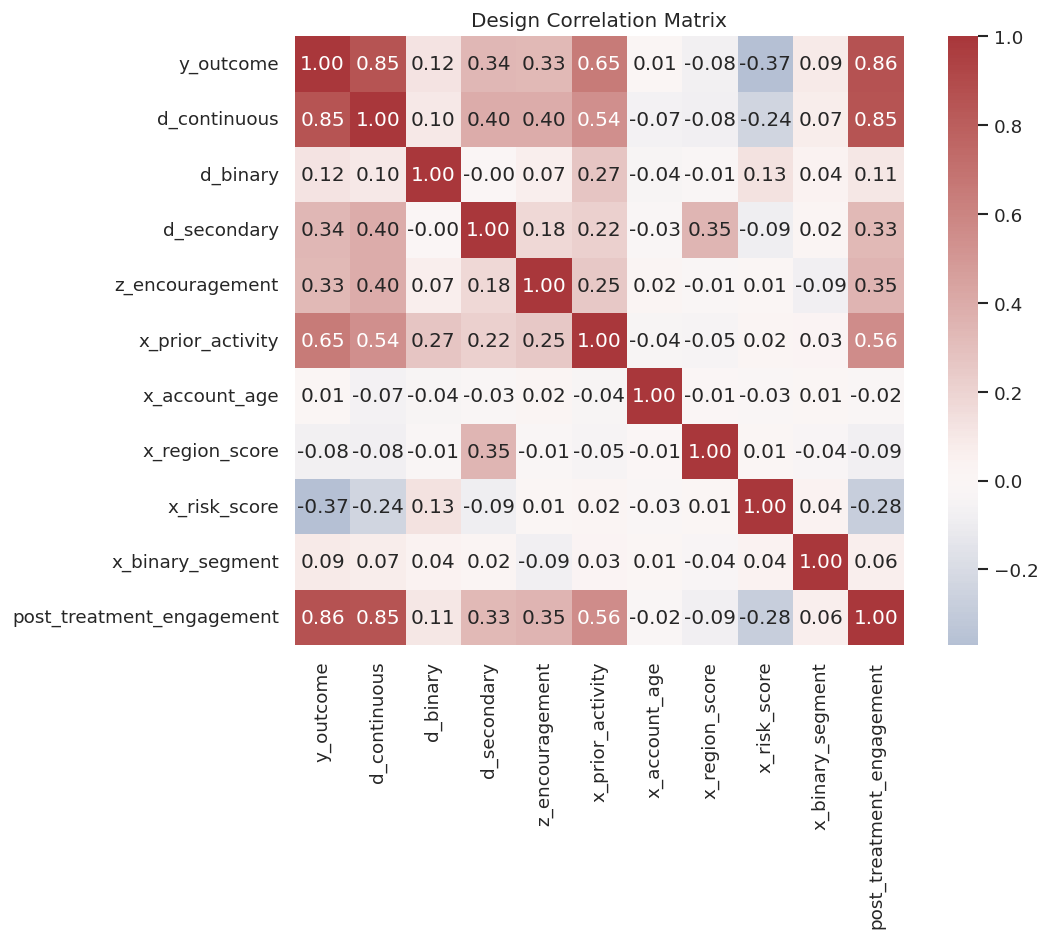

In [7]:
audit_cols = [
    "y_outcome",
    "d_continuous",
    "d_binary",
    "d_secondary",
    "z_encouragement",
    "x_prior_activity",
    "x_account_age",
    "x_region_score",
    "x_risk_score",
    "x_binary_segment",
    "post_treatment_engagement",
]
correlation_matrix = master_df[audit_cols].corr(numeric_only=True)
correlation_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_design_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Design Correlation Matrix")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_design_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


The post-treatment variable is highly related to the outcome and treatment, which is exactly why it is tempting and dangerous as a control. The instrument is related to the continuous treatment, which is useful for IV examples but still requires exclusion assumptions in real applications.



#### Backend Helper Functions

The next helper functions summarize DoubleML data objects in tables. This makes the output easy to compare across standard, IV, cluster, panel, RDD, and sample-selection designs.

In [8]:
# Define reusable helpers for the Backend Helper Functions section.
def as_list(value):
    """
    Idea: Normalize a scalar or iterable input into a list so downstream code can loop over it safely.
    
    Parameters
    ----------
    value : object
        Numeric value being converted, formatted, or compared.
    
    Returns
    -------
    list
        List representation of the input, with missing input converted to an empty list.
    """
    if value is None:
        return []
    if isinstance(value, (list, tuple)):
        return list(value)
    return [value]


def summarize_backend(name, backend, design_note):
    """
    Idea: Summarize the backend into a compact table for interpretation in the Backend Helper Functions section.
    
    Parameters
    ----------
    name : str
        Short name used for the saved artifact or scenario label.
    backend : object
        DoubleML data backend being summarized.
    design_note : object
        Text note describing the modeling role of a variable or design component.
    
    Returns
    -------
    dict[str, object]
        Dictionary summarizing DoubleMLData roles, column names, and dimensions.
    """
    fields = {
        "backend_name": name,
        "backend_class": backend.__class__.__name__,
        "outcome": getattr(backend, "y_col", None),
        "treatments": ", ".join(as_list(getattr(backend, "d_cols", None))),
        "controls": ", ".join(as_list(getattr(backend, "x_cols", None))),
        "instruments": ", ".join(as_list(getattr(backend, "z_cols", None))),
        "clusters": ", ".join(as_list(getattr(backend, "cluster_cols", None))),
        "time_col": getattr(backend, "t_col", None),
        "id_col": getattr(backend, "id_col", None),
        "score_col": getattr(backend, "score_col", None),
        "selection_col": getattr(backend, "s_col", None),
        "n_obs": getattr(backend, "n_obs", None),
        "design_note": design_note,
    }
    return fields


def role_overlap_report(role_map):
    """
    Idea: Compute the role overlap report needed in the Backend Helper Functions section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    role_map : object
        Mapping from variables to their causal or modeling roles.
    
    Returns
    -------
    pd.DataFrame
        Variable-role table showing overlap between supplied design roles.
    """
    rows = []
    seen = {}
    for role, columns in role_map.items():
        for column in as_list(columns):
            if column in seen:
                rows.append({"column": column, "first_role": seen[column], "second_role": role, "problem": "column assigned to multiple roles"})
            else:
                seen[column] = role
    return pd.DataFrame(rows)


The overlap helper catches one of the most common setup errors: the same column being assigned as both treatment and control, or as both instrument and control.

### Standard DoubleMLData for PLR

The standard cross-sectional backend uses `DoubleMLData`. We start with a continuous-treatment design suitable for PLR-style estimators.

The key choices are:

- `y_col="y_outcome"`;
- `d_cols="d_continuous"`;
- `x_cols` equal to pre-treatment controls only.

In [9]:
standard_x_cols = [
    "x_prior_activity",
    "x_account_age",
    "x_region_score",
    "x_risk_score",
    "x_binary_segment",
]

plr_backend = dml.DoubleMLData(
    master_df,
    y_col="y_outcome",
    d_cols="d_continuous",
    x_cols=standard_x_cols,
)
print(plr_backend)


================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y_outcome
Treatment variable(s): ['d_continuous']
Covariates: ['x_prior_activity', 'x_account_age', 'x_region_score', 'x_risk_score', 'x_binary_segment']
Instrument variable(s): None
No. Observations: 900
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Columns: 17 entries, user_id to selected
dtypes: float64(9), int64(8)
memory usage: 119.7 KB



The printed object should show one outcome, one treatment, five covariates, no instruments, and the full row count. This confirms the standard PLR-ready backend.

Now we save a compact backend summary. This is useful when comparing many design objects in one notebook.

In [10]:
backend_summaries = [
    summarize_backend(
        "standard_plr_continuous_treatment",
        plr_backend,
        "Continuous treatment with pre-treatment controls for PLR-style estimators.",
    )
]
backend_summary_table = pd.DataFrame(backend_summaries)
backend_summary_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_backend_summary_initial.csv", index=False)
display(backend_summary_table)

,backend_name,backend_class,outcome,treatments,controls,instruments,clusters,time_col,id_col,score_col,selection_col,n_obs,design_note
0,standard_plr_continuous_treatment,DoubleMLData,y_outcome,d_continuous,"x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",,,None,None,None,None,900,Continuous treatment with pre-treatment controls for PLR-style estimators.


The first backend is deliberately simple. The later backend objects add one design feature at a time.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### Binary-Treatment Backend for IRM

For binary-treatment models such as IRM, the backend still uses `DoubleMLData`. The difference is conceptual: `d_cols` now points to a binary treatment, and later model classes will use propensity-score-style nuisance functions.

In [11]:
irm_backend = dml.DoubleMLData(
    master_df,
    y_col="y_outcome",
    d_cols="d_binary",
    x_cols=standard_x_cols,
)

binary_treatment_audit = pd.DataFrame(
    [
        {
            "treatment": "d_binary",
            "unique_values": sorted(master_df["d_binary"].unique().tolist()),
            "treated_share": master_df["d_binary"].mean(),
            "control_share": 1 - master_df["d_binary"].mean(),
        }
    ]
)
binary_treatment_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_binary_treatment_audit.csv", index=False)
display(binary_treatment_audit.round(3))
print(irm_backend)


,treatment,unique_values,treated_share,control_share
0,d_binary,"[0, 1]",0.434,0.566


================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y_outcome
Treatment variable(s): ['d_binary']
Covariates: ['x_prior_activity', 'x_account_age', 'x_region_score', 'x_risk_score', 'x_binary_segment']
Instrument variable(s): None
No. Observations: 900
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Columns: 17 entries, user_id to selected
dtypes: float64(9), int64(8)
memory usage: 119.7 KB



The treated and control shares are both comfortably away from zero. This catches the extreme failure where one group is nearly absent. Conditional overlap still needs a separate check.

### Instrumental-Variable Backend

An IV setup adds `z_cols`. The instrument must be assigned explicitly; otherwise the backend will treat the design as non-IV. The package cannot verify the exclusion restriction for us. The data object can represent the intended instrument role.

In [12]:
iv_backend = dml.DoubleMLData(
    master_df,
    y_col="y_outcome",
    d_cols="d_continuous",
    x_cols=standard_x_cols,
    z_cols="z_encouragement",
)

iv_strength_screen = pd.DataFrame(
    [
        {
            "instrument": "z_encouragement",
            "treatment": "d_continuous",
            "corr_instrument_treatment": master_df[["z_encouragement", "d_continuous"]].corr().iloc[0, 1],
            "instrument_share": master_df["z_encouragement"].mean(),
        }
    ]
)
iv_strength_screen.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_iv_strength_screen.csv", index=False)
display(iv_strength_screen.round(3))
print(iv_backend)


,instrument,treatment,corr_instrument_treatment,instrument_share
0,z_encouragement,d_continuous,0.397,0.463


================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y_outcome
Treatment variable(s): ['d_continuous']
Covariates: ['x_prior_activity', 'x_account_age', 'x_region_score', 'x_risk_score', 'x_binary_segment']
Instrument variable(s): ['z_encouragement']
No. Observations: 900
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Columns: 17 entries, user_id to selected
dtypes: float64(9), int64(8)
memory usage: 119.7 KB



The instrument is related to the treatment in this synthetic data. In real IV work, relevance is only one requirement; exclusion and independence are design assumptions that need separate evidence.

#### Multi-Treatment Backend

`DoubleMLData` can hold multiple treatments. The argument `use_other_treat_as_covariate` controls whether other treatment variables are automatically included as controls when one treatment is targeted.

This is a subtle modeling choice. If treatments are jointly assigned, using the other treatment as a covariate changes the estimand from a total effect toward a partial effect holding the other treatment fixed.

In [13]:
# Fit or evaluate the model objects used in the Multi-Treatment Backend section.
multi_treatment_backend = dml.DoubleMLData(
    master_df,
    y_col="y_outcome",
    d_cols=["d_continuous", "d_secondary"],
    x_cols=standard_x_cols,
    use_other_treat_as_covariate=True,
)

multi_treatment_backend_no_auto = dml.DoubleMLData(
    master_df,
    y_col="y_outcome",
    d_cols=["d_continuous", "d_secondary"],
    x_cols=standard_x_cols,
    use_other_treat_as_covariate=False,
)

multi_treatment_policy = pd.DataFrame(
    [
        {
            "backend": "use_other_treat_as_covariate_true",
            "use_other_treat_as_covariate": True,
            "design_meaning": "Estimate each treatment effect while treating the other treatment as an additional adjustment variable.",
        },
        {
            "backend": "use_other_treat_as_covariate_false",
            "use_other_treat_as_covariate": False,
            "design_meaning": "Do not automatically adjust for the other treatment; use when the estimand is defined that way.",
        },
    ]
)
multi_treatment_policy.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_multi_treatment_policy.csv", index=False)
display(multi_treatment_policy)
print(multi_treatment_backend)


,backend,use_other_treat_as_covariate,design_meaning
0,use_other_treat_as_covariate_true,True,Estimate each treatment effect while treating the other treatment as an additional adjustment variable.
1,use_other_treat_as_covariate_false,False,Do not automatically adjust for the other treatment; use when the estimand is defined that way.


================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y_outcome
Treatment variable(s): ['d_continuous', 'd_secondary']
Covariates: ['x_prior_activity', 'x_account_age', 'x_region_score', 'x_risk_score', 'x_binary_segment']
Instrument variable(s): None
No. Observations: 900
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Columns: 17 entries, user_id to selected
dtypes: float64(9), int64(8)
memory usage: 119.7 KB



The object prints both treatments. The policy table is the important part: multi-treatment designs need an estimand decision before fitting.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### Clustered Backend

Cluster columns represent dependence across rows. Examples include repeated users, schools, stores, geographies, or sessions. In this installed version, cluster columns can be supplied directly to `DoubleMLData`, which is the preferred modern pattern.

In [14]:
cluster_backend = dml.DoubleMLData(
    master_df,
    y_col="y_outcome",
    d_cols="d_continuous",
    x_cols=standard_x_cols,
    cluster_cols="cluster_id",
)

cluster_audit = (
    master_df.groupby("cluster_id")
    .size()
    .rename("rows_per_cluster")
    .reset_index()
    .agg(
        n_clusters=("cluster_id", "size"),
        min_rows=("rows_per_cluster", "min"),
        median_rows=("rows_per_cluster", "median"),
        max_rows=("rows_per_cluster", "max"),
    )
    .reset_index(drop=True)
)
cluster_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cluster_audit.csv", index=False)
display(cluster_audit)
print(cluster_backend)


,cluster_id,rows_per_cluster
0,30.0,NaN
1,NaN,16.0
2,NaN,30.5
3,NaN,43.0


================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y_outcome
Treatment variable(s): ['d_continuous']
Covariates: ['x_prior_activity', 'x_account_age', 'x_region_score', 'x_risk_score', 'x_binary_segment']
Instrument variable(s): None
Cluster variable(s): ['cluster_id']
Is cluster data: True
No. Observations: 900
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Columns: 17 entries, user_id to selected
dtypes: float64(9), int64(8)
memory usage: 119.7 KB



The cluster audit shows enough groups and rows per group for a worked example. In real work, very few clusters or highly unbalanced clusters should be flagged before inference.

#### Panel Backend

Panel data has repeated observations for units over time. The `DoubleMLPanelData` backend requires both a time column and a unit identifier. We create a compact long-format panel dataset from scratch so the structure is obvious.

In [15]:
# Define reusable helpers for the Panel Backend section.
def simulate_panel_data(n_units=180, n_periods=4, seed=RANDOM_SEED):
    """
    Idea: Simulate the panel data scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    n_units : object
        Number of units generated for the panel or repeated-observation simulation.
    n_periods : object
        Number of time periods generated for the panel design.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    pd.DataFrame
        Dataset table for simulate panel data, with the variables needed by the tutorial design.
    """
    rng = np.random.default_rng(seed)
    rows = []
    unit_effect = rng.normal(size=n_units)
    for unit_id in range(n_units):
        baseline = rng.normal()
        for time_period in range(n_periods):
            x_time = rng.normal()
            treatment = 0.30 * baseline + 0.20 * time_period + rng.normal()
            outcome = 0.90 * treatment + 0.60 * baseline + 0.25 * x_time + unit_effect[unit_id] + rng.normal()
            rows.append(
                {
                    "unit_id": unit_id,
                    "time_period": time_period,
                    "y_outcome": outcome,
                    "d_continuous": treatment,
                    "x_baseline": baseline,
                    "x_time_varying": x_time,
                }
            )
    return pd.DataFrame(rows)

panel_df = simulate_panel_data()
panel_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_panel_teaching_data.csv", index=False)

panel_backend = dml.DoubleMLPanelData(
    panel_df,
    y_col="y_outcome",
    d_cols="d_continuous",
    x_cols=["x_baseline", "x_time_varying"],
    t_col="time_period",
    id_col="unit_id",
)

panel_audit = pd.DataFrame(
    [
        {
            "rows": len(panel_df),
            "unique_units": panel_df["unit_id"].nunique(),
            "unique_time_periods": panel_df["time_period"].nunique(),
            "rows_per_unit_min": panel_df.groupby("unit_id").size().min(),
            "rows_per_unit_max": panel_df.groupby("unit_id").size().max(),
        }
    ]
)
panel_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_panel_audit.csv", index=False)
display(panel_audit)
print(panel_backend)


,rows,unique_units,unique_time_periods,rows_per_unit_min,rows_per_unit_max
0,720,180,4,4,4


================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: y_outcome
Treatment variable(s): ['d_continuous']
Covariates: ['x_baseline', 'x_time_varying']
Instrument variable(s): None
Time variable: time_period
Id variable: unit_id
Static panel data: False
No. Unique Ids: 180
No. Observations: 720
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Columns: 6 entries, unit_id to x_time_varying
dtypes: float64(4), int64(2)
memory usage: 33.9 KB



The panel backend records the unit and time roles explicitly. This is safer than relying on row order or dataframe sorting.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### RDD Backend

Regression discontinuity designs require a running score and a treatment assignment around a cutoff. `DoubleMLRDDData` records the running score through `score_col`. The treatment indicator is still supplied through `d_cols`.

In [16]:
rdd_df = master_df.copy()
rdd_backend = dml.DoubleMLRDDData(
    rdd_df,
    y_col="y_outcome",
    d_cols="d_rdd",
    score_col="running_score",
    x_cols=standard_x_cols,
)

rdd_audit = pd.DataFrame(
    [
        {
            "score_col": "running_score",
            "cutoff_used_in_simulation": 0.0,
            "treated_share": rdd_df["d_rdd"].mean(),
            "min_score": rdd_df["running_score"].min(),
            "max_score": rdd_df["running_score"].max(),
            "rows_within_0_25_of_cutoff": (rdd_df["running_score"].abs() <= 0.25).sum(),
        }
    ]
)
rdd_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_rdd_audit.csv", index=False)
display(rdd_audit.round(3))
print(rdd_backend)


,score_col,cutoff_used_in_simulation,treated_share,min_score,max_score,rows_within_0_25_of_cutoff
0,running_score,0.0,0.497,-3.119,3.199,170


================== DoubleMLRDDData Object ==================
Score variable: running_score
Outcome variable: y_outcome
Treatment variable(s): ['d_rdd']
Covariates: ['x_prior_activity', 'x_account_age', 'x_region_score', 'x_risk_score', 'x_binary_segment']
Instrument variable(s): None
No. Observations: 900



The RDD audit checks local support around the cutoff. A running score with no observations near the cutoff would be a design problem before any model fitting.

The next figure shows the running score distribution and the cutoff. It is a quick visual check that the data has observations on both sides.

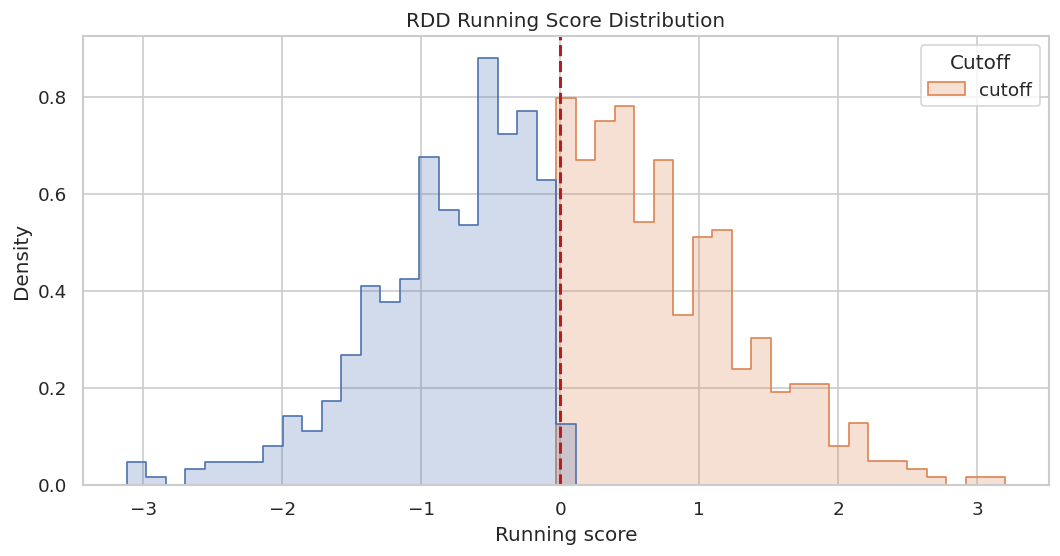

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.histplot(data=rdd_df, x="running_score", hue="d_rdd", bins=45, element="step", stat="density", common_norm=False, ax=ax)
ax.axvline(0, color="#b91c1c", linestyle="--", linewidth=1.8, label="cutoff")
ax.set_title("RDD Running Score Distribution")
ax.set_xlabel("Running score")
ax.set_ylabel("Density")
ax.legend(title="Cutoff", labels=["cutoff"])
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_rdd_running_score_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The distribution has support on both sides of zero. Later RDD modeling will need stronger checks, but this is the right backend-level starting point.

#### Sample-Selection Backend

Sample-selection models use a selection indicator, supplied as `s_col`. The key idea is that outcome observation or analytic inclusion may not be random. The backend needs the selection column so the model can represent that design.

In [18]:
selection_backend = dml.DoubleMLSSMData(
    master_df,
    y_col="y_outcome",
    d_cols="d_binary",
    x_cols=standard_x_cols,
    s_col="selected",
)

selection_audit = pd.DataFrame(
    [
        {
            "selection_col": "selected",
            "selected_share": master_df["selected"].mean(),
            "unselected_share": 1 - master_df["selected"].mean(),
            "rows": len(master_df),
        }
    ]
)
selection_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_selection_audit.csv", index=False)
display(selection_audit.round(3))
print(selection_backend)


,selection_col,selected_share,unselected_share,rows
0,selected,0.458,0.542,900


================== DoubleMLSSMData Object ==================
Selection variable: selected
Outcome variable: y_outcome
Treatment variable(s): ['d_binary']
Covariates: ['x_prior_activity', 'x_account_age', 'x_region_score', 'x_risk_score', 'x_binary_segment']
Instrument variable(s): None
No. Observations: 900



The selected share is neither zero nor one, so the selection indicator has variation. That is the first minimal requirement for a sample-selection design.




## Reporting and Takeaways

### Combined Backend Summary

Now we collect all constructed backend objects into one table. This table gives a compact view of how the same master data can support different designs when roles are assigned differently.

In [19]:
backend_objects = [
    ("standard_plr_continuous_treatment", plr_backend, "Continuous treatment with pre-treatment controls."),
    ("standard_irm_binary_treatment", irm_backend, "Binary treatment with pre-treatment controls."),
    ("iv_pliv_continuous_treatment", iv_backend, "Continuous treatment plus instrument."),
    ("multi_treatment", multi_treatment_backend, "Two treatment columns with other treatment used as covariate."),
    ("clustered_plr", cluster_backend, "Continuous treatment with cluster identifier."),
    ("panel_long_format", panel_backend, "Repeated unit-time observations."),
    ("rdd_running_score", rdd_backend, "RDD score and cutoff treatment."),
    ("sample_selection", selection_backend, "Selection indicator supplied."),
]
backend_summary_table = pd.DataFrame([summarize_backend(*item) for item in backend_objects])
backend_summary_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_backend_summary_table.csv", index=False)
display(backend_summary_table)


,backend_name,backend_class,outcome,treatments,controls,instruments,clusters,time_col,id_col,score_col,selection_col,n_obs,design_note
0,standard_plr_continuous_treatment,DoubleMLData,y_outcome,d_continuous,"x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",,,NaN,NaN,NaN,NaN,900,Continuous treatment with pre-treatment controls.
1,standard_irm_binary_treatment,DoubleMLData,y_outcome,d_binary,"x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",,,NaN,NaN,NaN,NaN,900,Binary treatment with pre-treatment controls.
2,iv_pliv_continuous_treatment,DoubleMLData,y_outcome,d_continuous,"x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",z_encouragement,,NaN,NaN,NaN,NaN,900,Continuous treatment plus instrument.
3,multi_treatment,DoubleMLData,y_outcome,"d_continuous, d_secondary","x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",,,NaN,NaN,NaN,NaN,900,Two treatment columns with other treatment used as covariate.
4,clustered_plr,DoubleMLData,y_outcome,d_continuous,"x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",,cluster_id,NaN,NaN,NaN,NaN,900,Continuous treatment with cluster identifier.
5,panel_long_format,DoubleMLPanelData,y_outcome,d_continuous,"x_baseline, x_time_varying",,,time_period,unit_id,NaN,NaN,720,Repeated unit-time observations.
6,rdd_running_score,DoubleMLRDDData,y_outcome,d_rdd,"x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",,,NaN,NaN,running_score,NaN,900,RDD score and cutoff treatment.
7,sample_selection,DoubleMLSSMData,y_outcome,d_binary,"x_prior_activity, x_account_age, x_region_score, x_risk_score, x_binary_segment",,,NaN,NaN,NaN,selected,900,Selection indicator supplied.


This table is the core output of the notebook. It shows the role assignment that each later estimator would inherit.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->




### Common Mistake: Overlapping Roles

DoubleML will often catch impossible role assignments, but it is better to catch them deliberately in your own audit. Here we create a mistaken role map that assigns `d_continuous` as both treatment and control.

In [20]:
bad_role_map = {
    "outcome": "y_outcome",
    "treatment": "d_continuous",
    "controls": standard_x_cols + ["d_continuous"],
}
overlap_problem_table = role_overlap_report(bad_role_map)
overlap_problem_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_overlapping_role_problem.csv", index=False)
display(overlap_problem_table)

,column,first_role,second_role,problem
0,d_continuous,treatment,controls,column assigned to multiple roles


The overlap audit catches the problem before model construction. This kind of check is worth automating in serious projects.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->




### Common Mistake: Post-Treatment Controls

A post-treatment variable may be highly predictive of the outcome, but it is usually unsafe as a standard control for the total effect of treatment. The code below flags controls that are not allowed by the variable dictionary.

In [21]:
proposed_controls_with_bad_control = standard_x_cols + ["post_treatment_engagement"]
allowed_lookup = variable_dictionary.set_index("column")["allowed_as_standard_control"].to_dict()
post_treatment_control_check = pd.DataFrame(
    [
        {
            "control": col,
            "allowed_as_standard_control": bool(allowed_lookup.get(col, False)),
            "role_family": variable_dictionary.set_index("column").loc[col, "role_family"] if col in allowed_lookup else "unknown",
        }
        for col in proposed_controls_with_bad_control
    ]
)
post_treatment_control_check["problem"] = ~post_treatment_control_check["allowed_as_standard_control"]
post_treatment_control_check.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_post_treatment_control_check.csv", index=False)
display(post_treatment_control_check)


,control,allowed_as_standard_control,role_family,problem
0,x_prior_activity,True,pre-treatment control,False
1,x_account_age,True,pre-treatment control,False
2,x_region_score,True,pre-treatment control,False
3,x_risk_score,True,pre-treatment control,False
4,x_binary_segment,True,pre-treatment control,False
5,post_treatment_engagement,False,post-treatment variable,True


The post-treatment variable is flagged. A backend object might still be constructible with that column, but the causal design would be different and usually not what we want for a total treatment effect.



### Common Mistake: Missing or Non-Finite Values

DoubleML backend constructors enforce finite controls by default. Here we intentionally create a missing value in one control column, catch the constructor error, and record the result as an audit table.

In [22]:
missing_df = master_df.copy()
missing_df.loc[0, "x_prior_activity"] = np.nan

missing_value_result = []
try:
    _ = dml.DoubleMLData(
        missing_df,
        y_col="y_outcome",
        d_cols="d_continuous",
        x_cols=standard_x_cols,
    )
    missing_value_result.append({"check": "construct_with_missing_control", "status": "unexpected_success", "message": "No error raised."})
except Exception as exc:
    missing_value_result.append({"check": "construct_with_missing_control", "status": "expected_failure", "message": str(exc)[:220]})

missing_value_check = pd.DataFrame(missing_value_result)
missing_value_check.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_missing_value_constructor_check.csv", index=False)
display(missing_value_check)


,check,status,message
0,construct_with_missing_control,expected_failure,Input contains NaN.


The constructor failure is helpful. It prevents silent fitting with an invalid design matrix. In applied work, decide on imputation or row exclusion before creating the backend object.



### Common Mistake: Weak Treatment Variation

For binary-treatment designs, a backend can be created even if one group is tiny. That is a design warning because propensity and outcome nuisance models need support in both groups. The code below creates a reusable treatment-variation audit.

In [23]:
# Define reusable helpers for the Common Mistake: Weak Treatment Variation section.
def binary_variation_audit(df, treatment_col):
    """
    Idea: Audit the binary variation audit and return checks that reveal design or data-quality problems.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    treatment_col : str
        Name of the treatment or intervention column.
    
    Returns
    -------
    pd.DataFrame
        Audit table showing whether binary variables vary enough for estimation.
    """
    counts = df[treatment_col].value_counts(dropna=False).sort_index()
    total = counts.sum()
    rows = []
    for value, count in counts.items():
        rows.append({"treatment_col": treatment_col, "value": value, "count": int(count), "share": count / total})
    result = pd.DataFrame(rows)
    result["minimum_group_share"] = result["share"].min()
    result["variation_warning"] = result["minimum_group_share"] < 0.05
    return result

binary_variation = binary_variation_audit(master_df, "d_binary")
rdd_variation = binary_variation_audit(master_df, "d_rdd")
variation_audit = pd.concat([binary_variation, rdd_variation], ignore_index=True)
variation_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_binary_treatment_variation_audit.csv", index=False)
display(variation_audit.round(3))


,treatment_col,value,count,share,minimum_group_share,variation_warning
0,d_binary,0,509,0.566,0.434,False
1,d_binary,1,391,0.434,0.434,False
2,d_rdd,0,453,0.503,0.497,False
3,d_rdd,1,447,0.497,0.497,False


Both binary treatment examples have support in each group. This clears the first backend-level check, although conditional overlap still needs inspection.

#### Common Mistake: Mechanical Control Selection

A tempting shortcut is to define controls as every numeric column except outcome and treatment. That shortcut can accidentally include identifiers, instruments, post-treatment variables, running scores, and selection indicators.

The code below contrasts mechanical controls with approved controls from the variable dictionary.

In [24]:
mechanical_controls = [
    col for col in master_df.select_dtypes(include=[np.number]).columns
    if col not in ["y_outcome", "d_continuous"]
]
approved_controls = variable_dictionary.loc[variable_dictionary["allowed_as_standard_control"], "column"].tolist()
mechanical_control_audit = pd.DataFrame(
    [
        {
            "column": col,
            "selected_mechanically": col in mechanical_controls,
            "approved_standard_control": col in approved_controls,
            "role_family": variable_dictionary.set_index("column").loc[col, "role_family"],
            "problem_if_used_as_standard_control": (col in mechanical_controls) and (col not in approved_controls),
        }
        for col in mechanical_controls
    ]
)
mechanical_control_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_mechanical_control_audit.csv", index=False)
display(mechanical_control_audit)


,column,selected_mechanically,approved_standard_control,role_family,problem_if_used_as_standard_control
0,user_id,True,False,identifier,True
1,cluster_id,True,False,cluster,True
2,time_period,True,False,time,True
3,d_binary,True,False,binary treatment,True
4,d_secondary,True,False,secondary treatment,True
5,z_encouragement,True,False,instrument,True
6,x_prior_activity,True,True,pre-treatment control,False
7,x_account_age,True,True,pre-treatment control,False
8,x_region_score,True,True,pre-treatment control,False
9,x_risk_score,True,True,pre-treatment control,False


The audit shows why column-selection shortcuts are dangerous. Numeric type is not the same thing as causal admissibility.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### Design Readiness Matrix

This matrix summarizes which checks matter for each design family. It is a bridge from backend construction to model fitting in later notebooks.

| design | required_backend | must_check |
| --- | --- | --- |
| PLR continuous treatment | DoubleMLData | pre-treatment controls, finite treatment, residual treatment variation |
| IRM binary treatment | DoubleMLData | binary treatment, overlap, treated/control support |
| PLIV continuous IV | DoubleMLData with z_cols | instrument role, relevance, exclusion story, treatment variation |
| IIVM binary IV | DoubleMLData with z_cols | binary treatment, instrument support, compliance logic |
| Clustered data | DoubleMLData with cluster_cols | cluster count, cluster balance, row dependence |
| Panel data | DoubleMLPanelData | unit id, time column, repeated observations, panel balance |
| RDD | DoubleMLRDDData | running score, cutoff support, treatment assignment rule |
| Sample selection | DoubleMLSSMData | selection variation, unselected rows retained, selection assumptions |


This matrix is intentionally conservative. Passing a backend constructor is a starting point, not a complete design validation.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->




#### Visual Summary of Backend Choices

The following plot counts how many columns are assigned to major roles in each backend object. It gives a quick visual overview of how role complexity changes across designs.

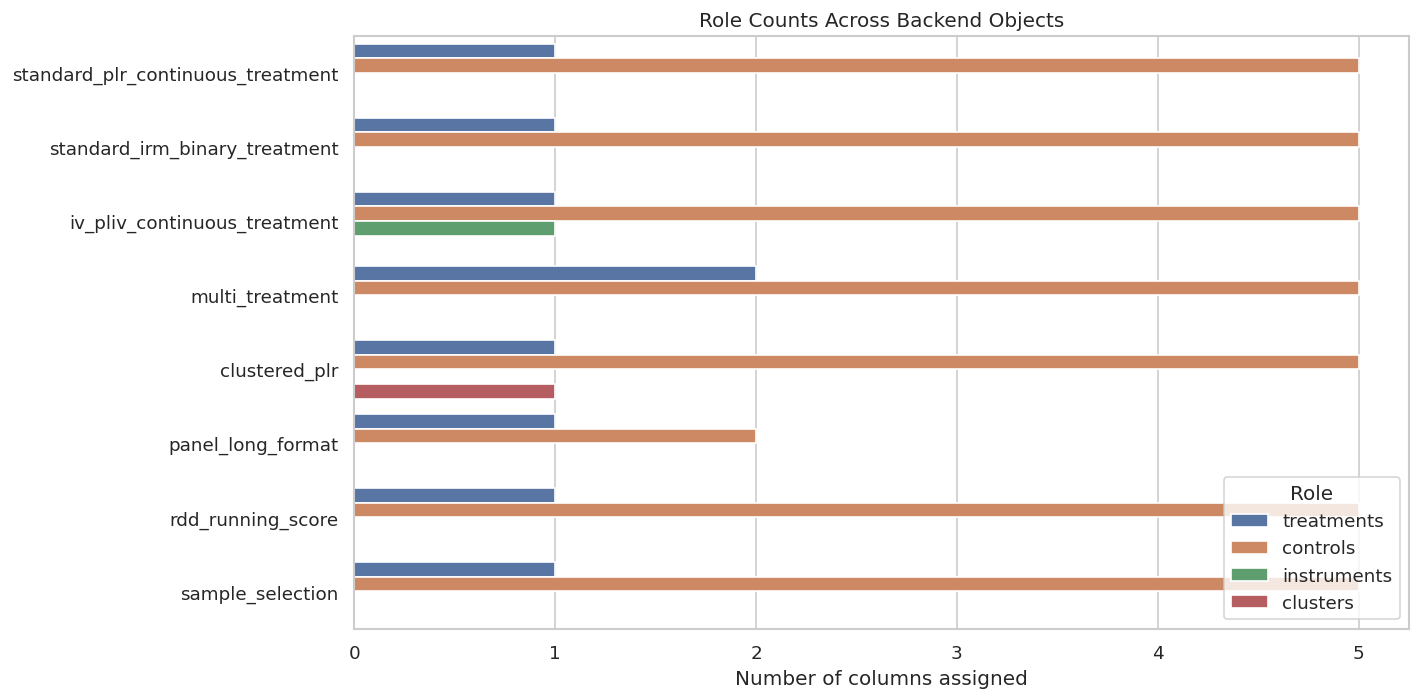

In [25]:
role_count_rows = []
for row in backend_summary_table.itertuples(index=False):
    role_count_rows.extend(
        [
            {"backend_name": row.backend_name, "role": "treatments", "count": len(as_list(row.treatments.split(", ") if row.treatments else []))},
            {"backend_name": row.backend_name, "role": "controls", "count": len(as_list(row.controls.split(", ") if row.controls else []))},
            {"backend_name": row.backend_name, "role": "instruments", "count": len(as_list(row.instruments.split(", ") if row.instruments else []))},
            {"backend_name": row.backend_name, "role": "clusters", "count": len(as_list(row.clusters.split(", ") if row.clusters else []))},
        ]
    )
role_count_table = pd.DataFrame(role_count_rows)
role_count_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_backend_role_counts.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=role_count_table, y="backend_name", x="count", hue="role", ax=ax)
ax.set_title("Role Counts Across Backend Objects")
ax.set_xlabel("Number of columns assigned")
ax.set_ylabel("")
ax.legend(title="Role", loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_backend_role_counts.png", dpi=160, bbox_inches="tight")
plt.show()


The plot shows that the same dataset supports different backend role structures. The backend should match the causal question, not the other way around.

#### Backend Construction Checklist

This checklist turns the notebook into a reusable pre-fit workflow. It should be completed before choosing nuisance learners or fitting a DoubleML estimator.

| step | question |
| --- | --- |
| State the estimand | What effect is targeted: continuous effect, ATE, IV effect, DID effect, RDD effect, or selection-adjusted effect? |
| Define outcome | Is the outcome measured after treatment and aligned with the causal question? |
| Define treatment | Is treatment continuous, binary, multi-valued, instrumented, or cutoff-assigned? |
| Define controls | Are controls pre-treatment variables, not mediators, colliders, identifiers, or post-treatment consequences? |
| Define instruments | If using IV, are instruments assigned through z_cols and backed by relevance/exclusion arguments? |
| Define dependence structure | Are clusters, units, and time columns represented explicitly when rows are dependent? |
| Audit missingness | Are all outcome, treatment, control, instrument, and design-specific columns finite or intentionally handled? |
| Audit variation | Does treatment, instrument, running score, or selection indicator have enough support? |
| Save backend summary | Can another analyst see exactly which columns were assigned to each role? |


The checklist is the main habit to carry forward. A careful backend setup makes the estimator notebooks much easier and less error-prone.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Reusable Backend Report Template

The final report template is a short markdown file that can be filled before model fitting. It is intentionally focused on design and column roles.

In [26]:
backend_report_template = """# DoubleML Backend Design Report

## 1. Causal Question

State the treatment, outcome, target population, and estimand.

## 2. Backend Class

Name the DoubleML backend class used and explain why it matches the design.

## 3. Column Roles

- Outcome column:
- Treatment column(s):
- Control columns:
- Instrument column(s):
- Cluster column(s):
- Unit/time columns:
- Running score column:
- Selection column:

## 4. Excluded Columns

List columns intentionally excluded from controls, especially identifiers, instruments, post-treatment variables, colliders, mediators, and target leakage columns.

## 5. Data Audit

Summarize missingness, finite-value checks, data types, treatment variation, binary-treatment support, instrument support, cluster counts, panel balance, RDD cutoff support, or selection support as relevant.

## 6. Assumption Notes

State the identification assumptions that must be defended outside the backend object.

## 7. Ready For Model Fitting?

State what remains to check before fitting: nuisance learner choice, sample splitting, tuning, inference, and sensitivity.
"""

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_backend_design_report_template.md"
report_path.write_text(backend_report_template)
print(report_path)


/home/apex/Documents/portfolio/notebooks/tutorials/doubleml/outputs/reports/02_backend_design_report_template.md


The template keeps the backend work visible. It is much easier to review a DoubleML analysis when the column roles are documented before model fitting begins.

#### Closing Notes

The backend is where the causal design becomes machine-readable. The main lesson is simple: choose columns by causal role, not by convenience, data type, or predictive power.

The next notebook moves from backend setup into `DoubleMLPLR`, where we estimate continuous-treatment effects using the data roles introduced here.